<a href="https://colab.research.google.com/github/shinae1023/AML_project/blob/main/earlyexit_entropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/biggsbenjamin/earlyexitnet
%cd earlyexitnet

Cloning into 'earlyexitnet'...
remote: Enumerating objects: 953, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 953 (delta 104), reused 168 (delta 76), pack-reused 738 (from 2)
Receiving objects: 100% (953/953), 84.70 MiB | 18.32 MiB/s, done.
Resolving deltas: 100% (496/496), done.
/content/earlyexitnet


In [3]:
!apt-get update
!apt-get install protobuf-compiler libprotoc-dev

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Hit:13 https://ppa.launchpadcontent.net/deadsnakes/p

In [4]:
!pip install .

Processing /content/earlyexitnet
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 158.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 146.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 139.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 132.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [6]:
import os
import re

# 1. train.py 패치
train_path = "/usr/local/lib/python3.12/dist-packages/earlyexitnet/training_tools/train.py"
if os.path.exists(train_path):
    with open(train_path, "r", encoding="utf-8") as f:
        content = f.read()

    if "B_Alexnet_cifar" not in content:
        content = content.replace("B_Lenet_cifar", "B_Lenet_cifar, B_Alexnet_cifar")
    if "'b_alexnet_cifar'" not in content:
        target = "elif model_str == 'resnet8':"
        insertion = "elif model_str == 'b_alexnet_cifar':\n        model = B_Alexnet_cifar()\n    "
        content = content.replace(target, insertion + target)

    with open(train_path, "w", encoding="utf-8") as f:
        f.write(content)
    print("1/2 train.py (AlexNet 인식) 패치 완료")

# 2. cli.py 패치
cli_path = "/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py"
if os.path.exists(cli_path):
    with open(cli_path, "r", encoding="utf-8") as f:
        content = f.read()

    # Tester 파라미터 매핑 버그 (TypeError 방지)
    pattern = re.compile(r'net_test\s*=\s*Tester\s*\([^)]*\)', re.DOTALL)
    fixed_code = """net_test = Tester(
            model=model, test_dl=test_dl, loss_f=loss_f, exits=exits,
            top1acc_thresholds=top1_thr, entropy_thresholds=entr_thr,
            conf_funcs=args.confidence_function, device=device, save_raw=save_raw
        )"""
    content = pattern.sub(fixed_code, content)

    # 다중 임계값 동적 확장 & Softmax/Entropy 자동 스위칭 버그 (NaN 방지)
    old_str = "[float(thresh)], None,loss_f,args"
    new_str = "[0.0]*(exits-1) if str(args.confidence_function) in ['0', 'entropy'] else [float(thresh)]*(exits-1), [float(thresh)]*(exits-1) if str(args.confidence_function) in ['0', 'entropy'] else [0.0]*(exits-1), loss_f, args"
    content = content.replace(old_str, new_str)

    with open(cli_path, "w", encoding="utf-8") as f:
        f.write(content)
    print("2/2 cli.py (평가 및 스캔) 패치 완료\n")
else:
    print("경로를 찾을 수 없음. earlyexitnet이 설치되어 있는지 확인하십시오.")

1/2 train.py (AlexNet 인식) 패치 완료
2/2 cli.py (평가 및 스캔) 패치 완료



In [7]:
!python -m earlyexitnet.cli -m b_lenet_se -d mnist -bbe 50 -jte 30 -bstr 256 -rn "my_scratch_lenet" -gpu 0 -nw 2 -t1 0 -entr 0

Model done: b_lenet_se
Model done: b_lenet_se
Device: cuda:0
Number of workers: 2
Loss function set
Training new network
pin memory = True
100% 9.91M/9.91M [00:02<00:00, 4.79MB/s]
100% 28.9k/28.9k [00:00<00:00, 127kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100% 4.54k/4.54k [00:00<00:00, 19.9MB/s]
Got training data, batch size: 256
backbone epochs: 50 joint epochs: 30
using bb optimiser -> adam-brn
using jt optimiser -> adam-brn
PRETRAINING BACKBONE FROM SCRATCH
Training final exit
Starting epoch: 1... raw t loss:0.003925602012164493 t1acc:0.6934115975935828
raw v loss:0.0014009959995746613 v accu:0.8904551630434783
Saved to: outputs/b_lenet_se/pre_Trn_bb_2026-05-21_070236/backbone-e1-2026-05-21_070241.pth
Starting epoch: 2... raw t loss:0.0010094302588137475 t1acc:0.9220630013368984
raw v loss:0.0006644842417343804 v accu:0.9460767663043478
Saved to: outputs/b_lenet_se/pre_Trn_bb_2026-05-21_070236/backbone-e2-2026-05-21_070245.pth
Starting epoch: 3... raw t loss:0.00056935301816892

In [9]:
!python -m earlyexitnet.cli -m b_alexnet_cifar -d cifar10 -bbe 50 -jte 30 -bstr 256 -rn "my_scratch_alexnet" -gpu 0 -nw 2 -t1 0 0 -entr 0 0 -cf 0

Model done: b_alexnet_cifar
Model done: b_alexnet_cifar
Device: cuda:0
Number of workers: 2
Loss function set
Training new network
pin memory = True
Got training data, batch size: 256
backbone epochs: 50 joint epochs: 30
using bb optimiser -> adam-brn
using jt optimiser -> adam-brn
PRETRAINING BACKBONE FROM SCRATCH
Training final exit
Starting epoch: 1... raw t loss:0.008280809622448988 t1acc:0.1725010016025641
raw v loss:0.007496208716661503 v accu:0.24078525641025642
Saved to: outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-21_070918/backbone-e1-2026-05-21_070939.pth
Starting epoch: 2... raw t loss:0.007486977978633382 t1acc:0.24108573717948717
raw v loss:0.007137514077700102 v accu:0.30028044871794873
Saved to: outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-21_070918/backbone-e2-2026-05-21_071001.pth
Starting epoch: 3... raw t loss:0.0070349455733473105 t1acc:0.303310296474359
raw v loss:0.006639902408306415 v accu:0.33703926282051283
Saved to: outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-21_0

In [10]:
!python -m earlyexitnet.cli -m resnet8_2ee -d cifar10 -bbe 50 -jte 30 -bstr 256 -rn "my_scratch_resnet" -gpu 0 -nw 2 -t1 0 -entr 0 -cf 0

Classif @ 0 linear dim: 512
Model done: resnet8_2ee
Model done: resnet8_2ee
Device: cuda:0
Number of workers: 2
Loss function set
Training new network
pin memory = True
Got training data, batch size: 256
backbone epochs: 50 joint epochs: 30
using bb optimiser -> adam-brn
using jt optimiser -> adam-brn
PRETRAINING BACKBONE FROM SCRATCH
Training final exit
Starting epoch: 1... raw t loss:0.007478999842603046 t1acc:0.29609875801282054
raw v loss:0.006622172318972074 v accu:0.3703926282051282
Saved to: outputs/resnet8_2ee/pre_Trn_bb_2026-05-21_073907/backbone-e1-2026-05-21_073929.pth
Starting epoch: 2... raw t loss:0.006268476550944914 t1acc:0.4050480769230769
raw v loss:0.0060837123638544325 v accu:0.4321915064102564
Saved to: outputs/resnet8_2ee/pre_Trn_bb_2026-05-21_073907/backbone-e2-2026-05-21_073950.pth
Starting epoch: 3... raw t loss:0.005788648205522735 t1acc:0.45763221153846156
raw v loss:0.005660231296832745 v accu:0.47676282051282054
Saved to: outputs/resnet8_2ee/pre_Trn_bb_2026

In [12]:
!mkdir -p outputs/b_lenet_se//range_notes
!python -m earlyexitnet.cli -m b_lenet_se -d mnist -mp outputs/b_lenet_se/pre_Trn_bb_2026-05-21_070236/pretrn-joint-e26-2026-05-21_070702.pth -t1 0 -entr 0 -tr 0.1 2.0 -ts 0.1 -bste 500 -np outputs/b_lenet_se/range_notes/ -gpu 0 -nw 2 -cf 0

Model done: b_lenet_se
Model: b_lenet_se
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/18, thresh: 0.1 		 [00:00/00:00]
Devi

In [13]:
!mkdir -p outputs/b_alexnet_cifar/range_notes
!python -m earlyexitnet.cli -m b_alexnet_cifar -d cifar10 -mp outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-21_070918/pretrn-joint-e29-2026-05-21_073727.pth -t1 0 0 -entr 0 0 -tr 0.1 2.0 -ts 0.1 -bste 500 -np outputs/b_alexnet_cifar/range_notes/ -gpu 0 -nw 2 -cf 0

Model done: b_alexnet_cifar
Model: b_alexnet_cifar
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/18, thresh: 0.1 		 [00:00/0

In [14]:
!mkdir -p outputs/resnet8_2ee/range_notes
!python -m earlyexitnet.cli -m resnet8_2ee -d cifar10 -mp outputs/resnet8_2ee/pre_Trn_bb_2026-05-21_073907/pretrn-joint-e27-2026-05-21_080552.pth -t1 0 -entr 0 -tr 0.1 2.0 -ts 0.1 -bste 500 -np outputs/resnet8_2ee/range_notes/ -gpu 0 -nw 2 -cf 0

Classif @ 0 linear dim: 512
Model done: resnet8_2ee
Model: resnet8_2ee
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/18, thr

In [18]:
!python -m earlyexitnet.cli -m b_lenet_se -d mnist -mp outputs/b_lenet_se/pre_Trn_bb_2026-05-21_070236/pretrn-joint-e26-2026-05-21_070702.pth -t1 0 -entr 0 -tr 0.1 2.0 -ts 0.1 -bste 500 -np outputs/b_lenet_se/range_notes/ -gpu 0 -nw 2 -cf 0

Model done: b_lenet_se
Model: b_lenet_se
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/18, thresh: 0.1 		 [00:00/00:00]
Devi

In [19]:
!python -m earlyexitnet.cli -m b_alexnet_cifar -d cifar10 -mp outputs/b_alexnet_cifar/pre_Trn_bb_2026-05-21_070918/pretrn-joint-e29-2026-05-21_073727.pth -t1 0 0 -entr 0 0 -tr 0.1 2.0 -ts 0.1 -bste 500 -np outputs/b_alexnet_cifar/range_notes/ -gpu 0 -nw 2 -cf 0

Model done: b_alexnet_cifar
Model: b_alexnet_cifar
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/18, thresh: 0.1 		 [00:00/0

In [20]:
!python -m earlyexitnet.cli -m resnet8_2ee -d cifar10 -mp outputs/resnet8_2ee/pre_Trn_bb_2026-05-21_073907/pretrn-joint-e27-2026-05-21_080552.pth -t1 0 -entr 0 -tr 0.1 2.0 -ts 0.1 -bste 500 -np outputs/resnet8_2ee/range_notes/ -gpu 0 -nw 2 -cf 0

Classif @ 0 linear dim: 512
Model done: resnet8_2ee
Model: resnet8_2ee
Loss default function set
Setting up for testing
Device: cuda:0
Number of workers: 2
pin memory = True
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:157: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  rt_string = dt.utcfromtimestamp(timedelta(seconds=int(running_time)).total_seconds()).strftime("%M:%S")
/usr/local/lib/python3.12/dist-packages/earlyexitnet/cli.py:158: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  tt_string = dt.utcfromtimestamp(timedelta(seconds=total_time).total_seconds()).strftime("%M:%S")

Running test 0/18, thr


📄 LeNet (MNIST) 로드됨: ./outputs/b_lenet_se/range_notes/b_lenet_se_multiple_2026-05-21_081611.json


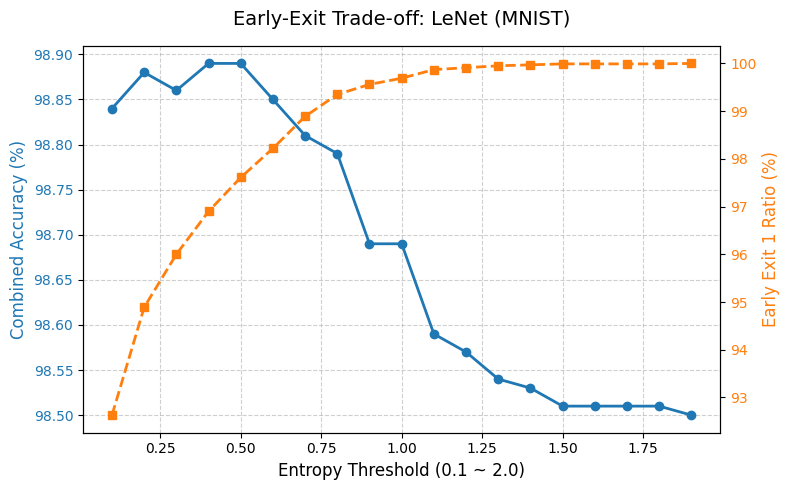


📄 AlexNet (CIFAR-10) 로드됨: ./outputs/b_alexnet_cifar/range_notes/b_alexnet_cifar_multiple_2026-05-21_081635.json


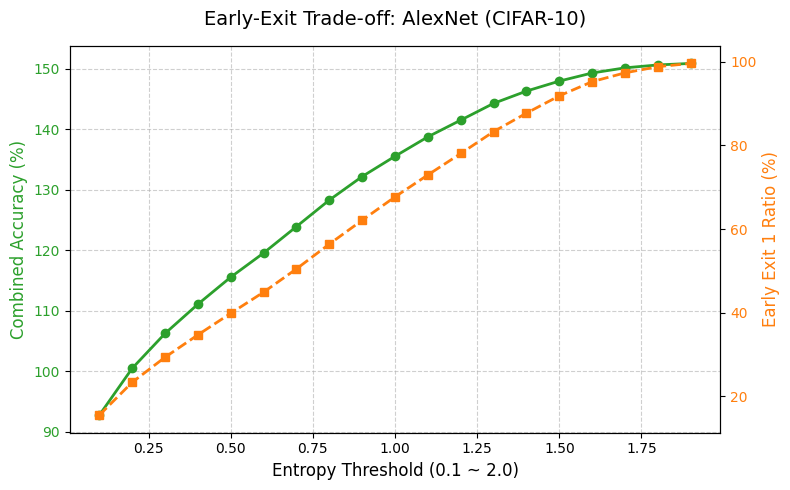


📄 ResNet8 (CIFAR-10) 로드됨: ./outputs/resnet8_2ee/range_notes/resnet8_2ee_multiple_2026-05-21_081703.json


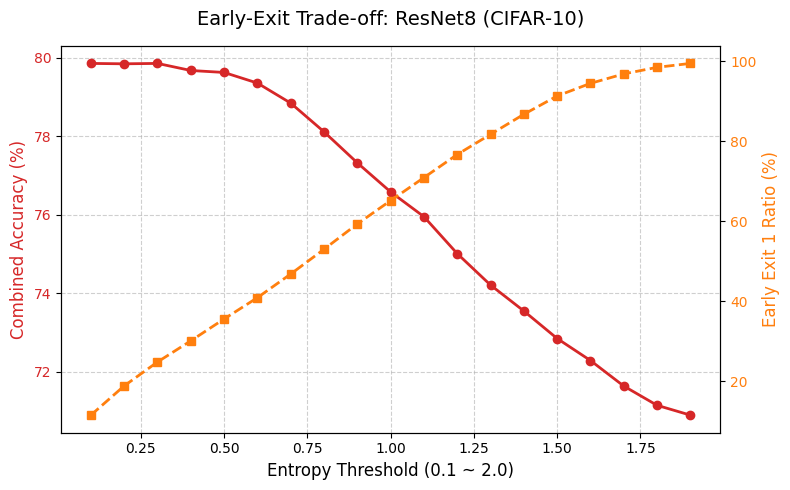

In [21]:
import json
import glob
import os
import math
import matplotlib.pyplot as plt

def force_float(val):
    if val is None: return 0.0
    if isinstance(val, str) and val.lower() in ['nan', 'null', 'none']: return 0.0
    try:
        f = float(val)
        return 0.0 if math.isnan(f) else f
    except:
        return 0.0

models = [
    {"name": "LeNet (MNIST)", "path": "./outputs/b_lenet_se/range_notes/*multiple*.json", "color": "tab:blue"},
    {"name": "AlexNet (CIFAR-10)", "path": "./outputs/b_alexnet_cifar/range_notes/*multiple*.json", "color": "tab:green"},
    {"name": "ResNet8 (CIFAR-10)", "path": "./outputs/resnet8_2ee/range_notes/*multiple*.json", "color": "tab:red"}
]

for m in models:
    json_files = glob.glob(m["path"])

    if not json_files:
        print(f"❌ {m['name']} 스캔 결과를 찾을 수 없음.")
        continue

    latest_json = max(json_files, key=os.path.getctime)
    print(f"\n📄 {m['name']} 로드됨: {latest_json}")

    with open(latest_json, "r") as f:
        data = json.load(f)

    test_vals = data.get("test_vals", [])
    if not test_vals:
        continue

    target_key = list(test_vals[0]["conf_metrics"].keys())[0]

    thresholds = []
    accuracies = []
    early_exit_pct = []

    for item in test_vals:
        metrics = item["conf_metrics"][target_key]
        thr = force_float(metrics["exit_threshs"][0])
        ee1 = force_float(metrics["exit_pc"][0])
        acc = force_float(metrics.get("combined_accuracy"))

        if acc == 0.0:
            acc_list = metrics.get("accu_pc", [])
            pc_list = metrics.get("exit_pc", [])
            calc_acc = 0.0
            for a, p in zip(acc_list, pc_list):
                if force_float(p) > 0 and force_float(a) > 0:
                    calc_acc += force_float(a) * force_float(p)
            acc = calc_acc

        if acc > 0:
            thresholds.append(thr)
            accuracies.append(acc * 100)
            early_exit_pct.append(ee1 * 100)

    if len(set(thresholds)) > 1: # 점이 1개 초과일 때만 그림
        fig, ax1 = plt.subplots(figsize=(8, 5))

        color_acc = m["color"]
        ax1.set_xlabel('Entropy Threshold (0.1 ~ 2.0)', fontsize=12)
        ax1.set_ylabel('Combined Accuracy (%)', color=color_acc, fontsize=12)
        ax1.plot(thresholds, accuracies, color=color_acc, marker='o', linewidth=2, label='Accuracy')
        ax1.tick_params(axis='y', labelcolor=color_acc)
        ax1.grid(True, linestyle='--', alpha=0.6)

        ax2 = ax1.twinx()
        color_ee = 'tab:orange'
        ax2.set_ylabel('Early Exit 1 Ratio (%)', color=color_ee, fontsize=12)
        ax2.plot(thresholds, early_exit_pct, color=color_ee, marker='s', linestyle='--', linewidth=2, label='EE1 Ratio')
        ax2.tick_params(axis='y', labelcolor=color_ee)

        plt.title(f'Early-Exit Trade-off: {m["name"]}', fontsize=14, pad=15)
        fig.tight_layout()
        plt.show()
    else:
        print(f"❌ {m['name']}: 여전히 점이 1개만 찍힘. 로그를 다시 확인해야 함.")